
# Natural Language Processing with Classification and Vector Spaces
## Course 1 Week 1: Sentiment Analysis with Logistic Regression

## 1: SETUP AND IMPORTS

In [139]:
%pip install numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import random
from typing import List, Dict, Tuple, Set

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

## 2: VOCABULARY AND FEATURE EXTRACTION

In [141]:
def build_vocabulary(tweets: List[str]) -> List[str]:
    vocabulary = set()

    for idx,tweet in enumerate(tweets):
        # simple tokenization and lowercase
        words = tweet.lower().split()
        print(f"words in tweet {idx} : ",words)

        # add each word to vocabulary
        for word in words:
            vocabulary.add(word)
    
    list_vocab = list(vocabulary)
    print("list vocab - ", list_vocab)

    sorted_res = sorted(list_vocab)
    print("sorted_res ",sorted_res)

    return sorted_res

In [142]:
sample_tweets = [
    "I am happy because I am learning NLP",
    "I am sad because I hate this movie", 
    "This movie is great and I love it",
    "Learning NLP is fun and exciting"
]

vocabulary = build_vocabulary(sample_tweets)
print(f"sample vocabulary : {vocabulary}")
print(f"length of sample vocabulary: {len(vocabulary)} ")

words in tweet 0 :  ['i', 'am', 'happy', 'because', 'i', 'am', 'learning', 'nlp']
words in tweet 1 :  ['i', 'am', 'sad', 'because', 'i', 'hate', 'this', 'movie']
words in tweet 2 :  ['this', 'movie', 'is', 'great', 'and', 'i', 'love', 'it']
words in tweet 3 :  ['learning', 'nlp', 'is', 'fun', 'and', 'exciting']
list vocab -  ['is', 'learning', 'hate', 'and', 'happy', 'sad', 'movie', 'it', 'because', 'love', 'fun', 'this', 'exciting', 'i', 'am', 'great', 'nlp']
sorted_res  ['am', 'and', 'because', 'exciting', 'fun', 'great', 'happy', 'hate', 'i', 'is', 'it', 'learning', 'love', 'movie', 'nlp', 'sad', 'this']
sample vocabulary : ['am', 'and', 'because', 'exciting', 'fun', 'great', 'happy', 'hate', 'i', 'is', 'it', 'learning', 'love', 'movie', 'nlp', 'sad', 'this']
length of sample vocabulary: 17 


### bag of words

In [143]:
def extract_bow_features(text: str, vocabulary: List[str]):
    # tokenize and normalize the input text
    words_in_text = set(text.lower().split())
    print(f'words_in_text : {words_in_text}')

    # create feature vector
    feature = []
    for word in vocabulary:
        # print(f"checking for vocab word ",word)
        if word in words_in_text:
            # print("Word in tweet - 1")
            feature.append(1)
        else:
            # print("Word not in tweet - 0")
            feature.append(0)
    
    return feature

In [144]:
text = "I am happy because I am learning NLP"
bow_features = extract_bow_features(text, vocabulary)
print("bow features - ",bow_features)
print("length of the bow feature ", len(bow_features))
print(f"number of 1s: {sum(bow_features)}, number of 0s: {len(bow_features)-sum(bow_features)}")


words_in_text : {'learning', 'happy', 'because', 'i', 'am', 'nlp'}
bow features -  [1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]
length of the bow feature  17
number of 1s: 6, number of 0s: 11


## 3: FREQUENCY-BASED FEATURES

In [145]:
def build_freqs(tweets: List[str], labels: List[int]) -> Dict[Tuple[str, int], int]:
    freq = {}

    for tweet, label in zip(tweets,labels):
        words = tweet.lower().split()
        # print("dealing with words ",words)

        # count frequencies for each word
        for word in words:
            # print(f"current status of freq: ",freq)
            # print(f"trying to get {[word,label]} : {freq.get((word, label), 0)}")
            freq[(word, label)] = freq.get((word, label), 0) + 1

    return freq

In [146]:
sample_tweets_labeled = [
    "I am happy because I am learning",
    "I am happy and I love learning",
    "I am sad because I am not learning", 
    "I am sad and I hate learning"
]
sample_labels = [1, 1, 0, 0]  # 1=positive, 0=negative

freqs = build_freqs(sample_tweets_labeled, sample_labels)
print("freq ",freqs)
print("FREQUENCY DICTIONARY EXAMPLE")
print("-" * 40)
for (word, sentiment), freq in sorted(freqs.items()):
    sentiment_str = "positive" if sentiment == 1 else "negative"
    print(f"('{word}', {sentiment_str}) → {freq}")

freq  {('i', 1): 4, ('am', 1): 3, ('happy', 1): 2, ('because', 1): 1, ('learning', 1): 2, ('and', 1): 1, ('love', 1): 1, ('i', 0): 4, ('am', 0): 3, ('sad', 0): 2, ('because', 0): 1, ('not', 0): 1, ('learning', 0): 2, ('and', 0): 1, ('hate', 0): 1}
FREQUENCY DICTIONARY EXAMPLE
----------------------------------------
('am', negative) → 3
('am', positive) → 3
('and', negative) → 1
('and', positive) → 1
('because', negative) → 1
('because', positive) → 1
('happy', positive) → 2
('hate', negative) → 1
('i', negative) → 4
('i', positive) → 4
('learning', negative) → 2
('learning', positive) → 2
('love', positive) → 1
('not', negative) → 1
('sad', negative) → 2


### FREQUENCY TABLE ANALYSIS

In [147]:
def create_frequency_table(freqs: Dict[Tuple[str, int], int]) -> pd.DataFrame:
    # get all unique words
    words = sorted(set([word for (word,_) in freqs.keys()]))

    # print("words : ",words)

    # create trhe table data
    table_data = []
    for word in words:
        pos_freq = freqs.get((word, 1), 0)
        neg_freq = freqs.get((word, 0), 0)

        # determine sentiment signal
        if pos_freq > neg_freq:
            signal = "Positive"
        elif pos_freq < neg_freq:
            signal = "Negative"
        else:
            signal = "Neutral"

        table_data.append({
            'Word' : word,
            'Positive_Freq' : pos_freq,
            'Negative_Freq' : neg_freq,
            'Sentiment_Signal': signal
        })

    return pd.DataFrame(table_data)

In [148]:
freq_table = create_frequency_table(freqs)
print("freq_table: ",freq_table)

freq_table:         Word  Positive_Freq  Negative_Freq Sentiment_Signal
0        am              3              3          Neutral
1       and              1              1          Neutral
2   because              1              1          Neutral
3     happy              2              0         Positive
4      hate              0              1         Negative
5         i              4              4          Neutral
6  learning              2              2          Neutral
7      love              1              0         Positive
8       not              0              1         Negative
9       sad              0              2         Negative


## 4: FEATURE EXTRACTION WITH FREQUENCIES

In [149]:
def extract_features(tweet: str, freqs: Dict[Tuple[str, int], int]) -> np.ndarray:
    # tokenize the tweet
    words = tweet.lower().split()
    # print("words : ",words)

    # initialize the features
    bias = 1
    pos_sum = 0
    neg_sum = 0

    # sum the frequencies for each word
    for word in words:
        # print(f"word in words : ",word)
        # print(f"pos_sum : {pos_sum} and neg_sum: {neg_sum}")
        # print(f"get value for positive key ({word},1) : {freqs.get((word, 1), 0)}")
        # print(f"get value for negative key ({word},0) : {freqs.get((word, 1), 0)}")
        pos_sum += freqs.get((word, 1), 0)
        neg_sum += freqs.get((word, 0), 0)

    return  np.array([bias, pos_sum, neg_sum])

    

In [150]:
tweet_example = "I am learning NLP and I am sad"
features = extract_features(tweet_example, freqs)
print(f"features : ",features)
print(f"[bias={features[0]}, pos_sum={features[1]}, neg_sum={features[2]}]")

features :  [ 1 17 19]
[bias=1, pos_sum=17, neg_sum=19]


## 5: TEXT PREPROCESSING

In [151]:
def process_tweet(tweet: str) -> List[str]:
    """
    Complete preprocessing pipeline for tweets
    
    Args:
        tweet: Raw tweet string
    
    Returns:
        processed_words: List of cleaned words
    """
    # Step 1: Remove handles and URLs
    tweet = re.sub(r'@\w+', '', tweet)  # @john_doe
    # print("cleaned handles - tweet : ",tweet)
    tweet = re.sub(r'http\S+|https\S+|www\S+', '', tweet)   # http://www.example.com | https://www.example.com | www.example.com
    # print("cleaned urls - tweet : ",tweet)

    # Step 2: Tokenize
    words = tweet.split()
    # print("s2 - words: ",words)

    # Step 3: Remove stop words and punctuation
    stop_words = {
        'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves',
        'you', 'your', 'yours', 'yourself', 'yourselves',
        'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself',
        'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
        'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those',
        'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
        'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing',
        'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as',
        'until', 'while', 'of', 'at', 'by', 'for', 'with', 'through',
        'during', 'before', 'after', 'above', 'below', 'up', 'down',
        'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further',
        'then', 'once'
    }

    cleaned_words = []

    for word in words:
        # remove punctuations and convert to lowercase
        word_clean = re.sub(r'[^\w\s]', '', word.lower())
        # print("word clean - ",word_clean)

        # Skip if empty, stop word, or non-alphabetic
        if word_clean and word_clean not in stop_words and word_clean.isalpha():
            # Step 4: Simple stemming
            if word_clean.endswith('ing') and len(word_clean) > 4:
                word_clean = word_clean[:-3]
            elif word_clean.endswith('ed') and len(word_clean) > 3:
                word_clean = word_clean[:-2]
            elif word_clean.endswith('er') and len(word_clean) > 3:
                word_clean = word_clean[:-2]
            elif word_clean.endswith('ly') and len(word_clean) > 3:
                word_clean = word_clean[:-2]
            
            # Step 5: Add to cleaned words (already lowercase)
            cleaned_words.append(word_clean)

    return cleaned_words



    

In [152]:
# Example: Text preprocessing
original_tweet = "@JohnDoe and @JaneDoe are tuning a GREAT AI model at https://example.com hurray!!!"
processed = process_tweet(original_tweet)
print("processed : ",processed)

processed :  ['tun', 'great', 'ai', 'model', 'hurray']


## 6: COMPLETE FEATURE MATRIX CONSTRUCTION

In [153]:
def build_feature_matrix(tweets: List[str], labels: List[int]) -> Tuple[np.ndarray, Dict]:
    m = len(tweets)

    # step 1 : preprocess all tweets and build frequency dictionary
    processed_tweets = []
    freqs = {}

    for tweet, label in zip(tweets, labels):
        processed_tweet = process_tweet(tweet)
        # print("processed_tweet : ",processed_tweet)
        processed_tweets.append(processed_tweet)
        
        # build frequency dictionary
        for word in processed_tweet:
            freqs[(word, label)] = freqs.get((word, label), 0) + 1

    # print("processed_tweets ", processed_tweets)
    # print("freqs : ", freqs)

    # step 2 : build the feature matrix
    X = np.zeros((m,3))

    for i, processed_tweet in enumerate(processed_tweets):
        # print(f"tweet - idx = {i+1} -> processed_tweet = {processed_tweet}")
        # extract features using frequency dictionary
        bias = 1
        pos_sum = neg_sum = 0

        for word in processed_tweet:
            # print(f"word = {word} , pos_sum={freqs.get((word, 1) , 0)} and neg_sum={freqs.get((word, 0) , 0)}")
            pos_sum += freqs.get((word, 1) , 0)
            neg_sum += freqs.get((word, 0), 0)

        X[i, :] = [bias, pos_sum, neg_sum]

    return X, freqs

In [154]:
sample_tweets_complete = [
    "I am happy because I am learning NLP @deeplearning",
    "@user This movie is amazing!!! https://link.com", 
    "I hate this terrible film",
    "Love this great content and amazing work!",
    "This is the worst movie ever made"
]
sample_labels_complete = [1, 1, 0, 1, 0]  # 1=positive, 0=negative

X, freqs_complete = build_feature_matrix(sample_tweets_complete,sample_labels_complete )
print("X : ")
print(X)
print("shape of X ",X.shape)



X : 
[[1. 3. 0.]
 [1. 3. 1.]
 [1. 0. 3.]
 [1. 6. 0.]
 [1. 1. 4.]]
shape of X  (5, 3)


## 7: LOGISTIC REGRESSION IMPLEMENTATION

In [155]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """
    Sigmoid function with numerical stability

    Args:
        z: Input array

    Returns:
        Sigmoid of z
    """
    # Clip z to prevent overflow
    z_clipped = np.clip(z, -250, 250)
    return 1 / (1 + np.exp(-z_clipped))

In [156]:
def compute_cost(h: np.ndarray, y: np.ndarray) -> float:
    """
    Compute logistic regression cost function

    Args:
        h: Predictions
        y: True labels

    Returns:
        cost: Scalar cost value
    """
    m = len(y)
    # Clip predictions to avoid log(0)
    h_clipped = np.clip(h, 1e-15, 1 - 1e-15)
    cost = -(1/m) * np.sum(y * np.log(h_clipped) + (1 - y) * np.log(1 - h_clipped))
    return cost


In [157]:
def compute_gradient(X: np.ndarray, h: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Compute gradient for logistic regression
    
    Args:
        X: Feature matrix
        h: Predictions
        y: True labels
    
    Returns:
        gradient: Gradient vector
    """
    m = len(y)
    gradient = (1/m) * X.T.dot(h - y)
    return gradient

In [158]:
# Example: Testing logistic regression components
theta_example = np.array([0.0001, 0.0015, -0.0012])
z_example = X.dot(theta_example)
h_example = sigmoid(z_example)

print(f"\n🧮 LOGISTIC REGRESSION COMPONENTS")
print(f"Parameters θ: {theta_example}")
print(f"Linear combination z: {z_example}")
print(f"Predictions h: {h_example}")
print(f"Cost: {compute_cost(h_example, np.array(sample_labels_complete)):.4f}")


🧮 LOGISTIC REGRESSION COMPONENTS
Parameters θ: [ 0.0001  0.0015 -0.0012]
Linear combination z: [ 0.0046  0.0034 -0.0035  0.0091 -0.0032]
Predictions h: [0.50115    0.50085    0.499125   0.50227498 0.4992    ]
Cost: 0.6908


## 8: TRAINING LOGISTIC REGRESSION

In [159]:
def train_logistic_regression(X: np.ndarray, y: np.ndarray, 
                            alpha: float = 0.01, 
                            max_iterations: int = 1000, 
                            tolerance: float = 1e-6) -> Tuple[np.ndarray, List[float]]:
    """
    Train logistic regression using gradient descent
    
    Args:
        X: Feature matrix (m, n)
        y: Labels (m,)
        alpha: Learning rate
        max_iterations: Maximum iterations
        tolerance: Convergence threshold
    
    Returns:
        theta: Learned parameters
        costs: Cost history
    """
    m, n = X.shape
    
    # Initialize parameters
    theta = np.random.normal(0, 0.01, n)
    costs = []
    
    print(f"🚀 Training logistic regression...")
    print(f"Dataset: {m} examples, {n} features")
    print(f"Learning rate: {alpha}")
    
    for i in range(max_iterations):
        # Forward pass
        z = X.dot(theta)
        h = sigmoid(z)
        
        # Compute cost
        cost = compute_cost(h, y)
        costs.append(cost)
        
        # Compute gradient
        gradient = compute_gradient(X, h, y)
        
        # Update parameters
        theta = theta - alpha * gradient
        
        # Print progress
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")
        
        # Check convergence
        if i > 0 and abs(costs[-2] - costs[-1]) < tolerance:
            print(f"✅ Converged after {i+1} iterations")
            break
    
    print(f"🎯 Final cost: {costs[-1]:.4f}")
    print(f"📊 Final parameters: {theta}")
    
    return theta, costs


In [160]:
# Train the model
theta_trained, cost_history = train_logistic_regression(X, np.array(sample_labels_complete), alpha=0.1)


🚀 Training logistic regression...
Dataset: 5 examples, 3 features
Learning rate: 0.1
Iteration 0: Cost = 0.6981
Iteration 100: Cost = 0.0289
Iteration 200: Cost = 0.0149
Iteration 300: Cost = 0.0100
Iteration 400: Cost = 0.0076
Iteration 500: Cost = 0.0061
Iteration 600: Cost = 0.0051
Iteration 700: Cost = 0.0044
Iteration 800: Cost = 0.0038
Iteration 900: Cost = 0.0034
🎯 Final cost: 0.0031
📊 Final parameters: [ 0.11742609  2.25472132 -1.97421961]


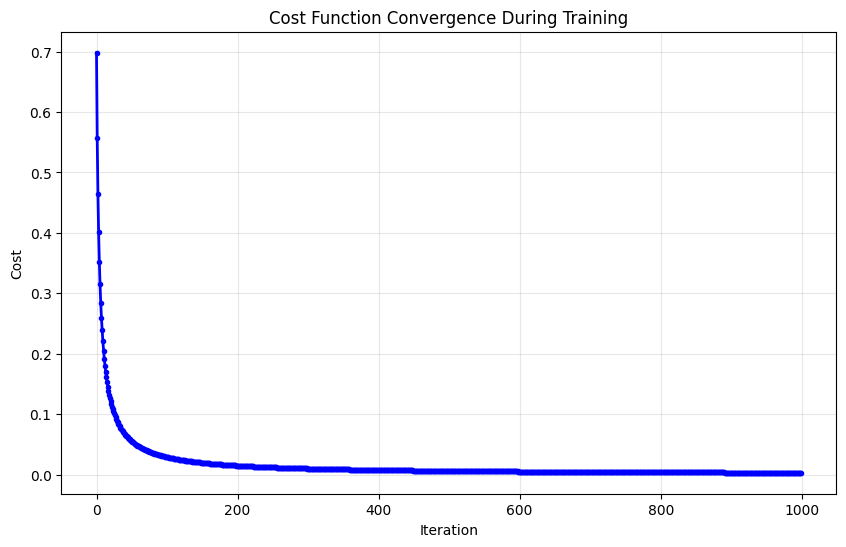

📈 Initial cost: 0.6981
📉 Final cost: 0.0031
📊 Cost reduction: 0.6950


In [161]:
def plot_cost_convergence(costs: List[float]):
    """
    Plot cost function convergence during training
    """
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(costs)), costs, 'b-', linewidth=2, marker='o', markersize=3)
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title('Cost Function Convergence During Training')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"📈 Initial cost: {costs[0]:.4f}")
    print(f"📉 Final cost: {costs[-1]:.4f}")
    print(f"📊 Cost reduction: {costs[0] - costs[-1]:.4f}")

# Plot training progress
plot_cost_convergence(cost_history)

## 9: MODEL TESTING AND EVALUATION

In [162]:
def test_logistic_regression(X_test: np.ndarray, y_test: np.ndarray, 
                           theta: np.ndarray, threshold: float = 0.5) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Test logistic regression model on test data
    
    Args:
        X_test: Test feature matrix
        y_test: True test labels
        theta: Trained parameters
        threshold: Classification threshold
    
    Returns:
        accuracy: Fraction of correct predictions
        predictions: Binary predictions
        probabilities: Sigmoid probabilities
    """
    # Compute probabilities
    z = X_test.dot(theta)
    probabilities = sigmoid(z)
    
    # Make binary predictions
    predictions = (probabilities >= threshold).astype(int)
    
    # Compute accuracy
    accuracy = np.mean(predictions == y_test)
    
    return accuracy, predictions, probabilities

def detailed_evaluation(X_test: np.ndarray, y_test: np.ndarray, theta: np.ndarray):
    """
    Detailed model evaluation with predictions analysis
    """
    accuracy, predictions, probabilities = test_logistic_regression(X_test, y_test, theta)
    
    print(f"\n🎯 MODEL EVALUATION RESULTS")
    print("=" * 45)
    print(f"Test accuracy: {accuracy:.1%}")
    print(f"Test examples: {len(y_test)}")
    
    print(f"\n📊 DETAILED PREDICTIONS:")
    print(f"{'Example':<8} {'Prob':<6} {'Pred':<5} {'True':<5} {'Correct'}")
    print("-" * 35)
    
    for i in range(len(y_test)):
        prob = probabilities[i]
        pred = predictions[i]
        true = y_test[i]
        correct = "✓" if pred == true else "✗"
        
        print(f"{i+1:<8} {prob:.3f}  {pred:<5} {true:<5} {correct}")
    
    return accuracy, predictions, probabilities

# Test the trained model (using same data for demonstration)
accuracy, preds, probs = detailed_evaluation(X, np.array(sample_labels_complete), theta_trained)



🎯 MODEL EVALUATION RESULTS
Test accuracy: 100.0%
Test examples: 5

📊 DETAILED PREDICTIONS:
Example  Prob   Pred  True  Correct
-----------------------------------
1        0.999  1     1     ✓
2        0.993  1     1     ✓
3        0.003  0     0     ✓
4        1.000  1     1     ✓
5        0.004  0     0     ✓


## 10: PREDICTION ON NEW TWEETS

In [163]:
def predict_sentiment(tweet: str, freqs: Dict[Tuple[str, int], int], theta: np.ndarray) -> Tuple[str, float]:
    """
    Predict sentiment for a new tweet
    
    Args:
        tweet: Input tweet string
        freqs: Frequency dictionary
        theta: Trained parameters
    
    Returns:
        sentiment: "Positive" or "Negative"
        confidence: Prediction probability
    """
    # Preprocess tweet
    processed_words = process_tweet(tweet)
    
    # Extract features
    bias = 1
    pos_sum = sum(freqs.get((word, 1), 0) for word in processed_words)
    neg_sum = sum(freqs.get((word, 0), 0) for word in processed_words)
    features = np.array([bias, pos_sum, neg_sum])
    
    # Make prediction
    z = theta.dot(features)
    probability = sigmoid(z)
    
    sentiment = "Positive" if probability >= 0.5 else "Negative"
    confidence = probability if probability >= 0.5 else 1 - probability
    
    return sentiment, confidence

# Test predictions on new tweets
test_tweets = [
    "I love this amazing movie!",
    "This film is terrible and boring", 
    "The weather is nice today",
    "I hate when people are rude",
    "Learning NLP is fantastic and exciting!"
]

print(f"\n🔮 PREDICTIONS ON NEW TWEETS")
print("=" * 50)

for tweet in test_tweets:
    sentiment, confidence = predict_sentiment(tweet, freqs_complete, theta_trained)
    print(f"Tweet: '{tweet}'")
    print(f"Prediction: {sentiment} (confidence: {confidence:.1%})")
    print()



🔮 PREDICTIONS ON NEW TWEETS
Tweet: 'I love this amazing movie!'
Prediction: Positive (confidence: 99.9%)

Tweet: 'This film is terrible and boring'
Prediction: Negative (confidence: 97.9%)

Tweet: 'The weather is nice today'
Prediction: Positive (confidence: 52.9%)

Tweet: 'I hate when people are rude'
Prediction: Negative (confidence: 86.5%)

Tweet: 'Learning NLP is fantastic and exciting!'
Prediction: Positive (confidence: 99.0%)



## 11: COMPLETE PIPELINE DEMONSTRATION

In [164]:
def sentiment_analysis_pipeline(raw_tweets: List[str], labels: List[int], 
                               test_tweets: List[str] = None) -> Dict:
    """
    Complete sentiment analysis pipeline from raw tweets to predictions
    
    Args:
        raw_tweets: Training tweets
        labels: Training labels
        test_tweets: Optional test tweets for prediction
    
    Returns:
        results: Dictionary with model components and results
    """
    print("🚀 COMPLETE SENTIMENT ANALYSIS PIPELINE")
    print("=" * 50)
    
    # Step 1: Build feature matrix
    print("📊 Step 1: Building feature matrix...")
    X, freqs = build_feature_matrix(raw_tweets, labels)
    print(f"✅ Feature matrix shape: {X.shape}")
    
    # Step 2: Train model
    print(f"\n🎯 Step 2: Training logistic regression...")
    theta, costs = train_logistic_regression(X, np.array(labels), alpha=0.1, max_iterations=500)
    
    # Step 3: Evaluate on training data
    print(f"\n📈 Step 3: Evaluating model...")
    accuracy, _, _ = test_logistic_regression(X, np.array(labels), theta)
    print(f"✅ Training accuracy: {accuracy:.1%}")
    
    # Step 4: Make predictions on new tweets
    if test_tweets:
        print(f"\n🔮 Step 4: Predicting new tweets...")
        for tweet in test_tweets:
            sentiment, confidence = predict_sentiment(tweet, freqs, theta)
            print(f"'{tweet}' → {sentiment} ({confidence:.1%})")
    
    return {
        'X': X,
        'freqs': freqs,
        'theta': theta,
        'costs': costs,
        'accuracy': accuracy
    }

# Run complete pipeline
results = sentiment_analysis_pipeline(
    raw_tweets=sample_tweets_complete,
    labels=sample_labels_complete,
    test_tweets=["I love learning!", "This is terrible", "Great job everyone!"]
)

print(f"\n🎉 PIPELINE COMPLETE!")
print(f"✅ Model trained successfully with {results['accuracy']:.1%} accuracy")
print(f"📚 Ready for Week 2: Naive Bayes!")

🚀 COMPLETE SENTIMENT ANALYSIS PIPELINE
📊 Step 1: Building feature matrix...
✅ Feature matrix shape: (5, 3)

🎯 Step 2: Training logistic regression...
🚀 Training logistic regression...
Dataset: 5 examples, 3 features
Learning rate: 0.1
Iteration 0: Cost = 0.6928
Iteration 100: Cost = 0.0289
Iteration 200: Cost = 0.0149
Iteration 300: Cost = 0.0100
Iteration 400: Cost = 0.0076
🎯 Final cost: 0.0061
📊 Final parameters: [ 0.10907507  1.96024451 -1.73385436]

📈 Step 3: Evaluating model...
✅ Training accuracy: 100.0%

🔮 Step 4: Predicting new tweets...
'I love learning!' → Positive (98.3%)
'This is terrible' → Negative (83.5%)
'Great job everyone!' → Positive (88.8%)

🎉 PIPELINE COMPLETE!
✅ Model trained successfully with 100.0% accuracy
📚 Ready for Week 2: Naive Bayes!
